## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.7 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -------- ------------------------------- 1/5 [multitasking]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [2]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
# 구글 주식 데이터 로딩
goog = yf.download("GOOG", start="2004-01-01", end="2024-12-31")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.478782,2.570680,2.370580,2.470382,897427216
2004-08-20,2.675672,2.694694,2.482735,2.495333,458857488
2004-08-23,2.702599,2.803390,2.693953,2.735949,366857939
2004-08-24,2.590691,2.756947,2.558575,2.748054,306396159
2004-08-25,2.618605,2.668014,2.566233,2.592913,184645512


In [5]:
# [+] 종가(Close) 데이터만 사용하기
goog = goog['Close']
goog

Ticker,GOOG
Date,
2004-08-19,2.478782
2004-08-20,2.675672
2004-08-23,2.702599
2004-08-24,2.590691
2004-08-25,2.618605
...,...
2024-12-23,195.092529
2024-12-24,196.665283
2024-12-26,196.197433


<Axes: xlabel='Date'>

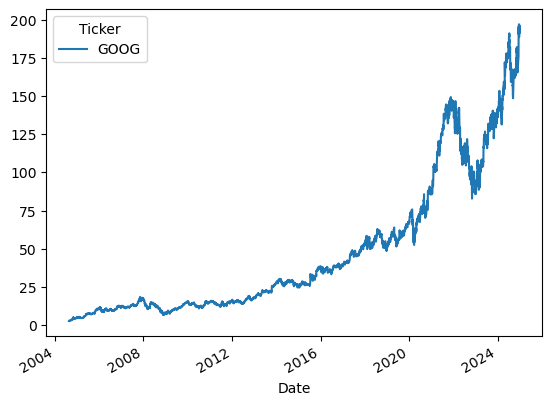

In [6]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [8]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('ME').mean()
goog_downsampled

Ticker,GOOG
Date,
2004-08-31,2.600380
2004-09-30,2.797144
2004-10-31,3.785391
2004-11-30,4.384811
2004-12-31,4.490415
...,...
2024-08-31,164.161283
2024-09-30,158.386140
2024-10-31,165.953079


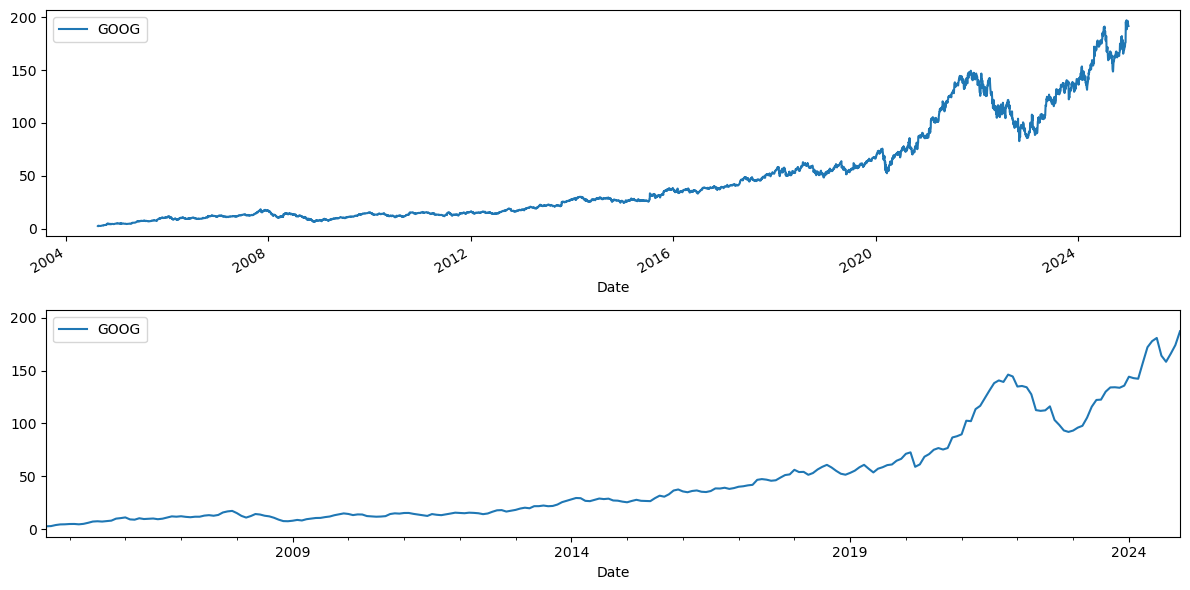

In [9]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

Ticker            GOOG
Date                  
2004-08-31    2.528930
2004-09-30    3.201616
2004-10-31         NaN
2004-11-30    4.495602
2004-12-31    4.762651
...                ...
2024-07-31  171.935455
2024-08-31         NaN
2024-09-30  166.235825
2024-10-31  171.704422
2024-11-30         NaN

[244 rows x 1 columns]


<Axes: xlabel='Date'>

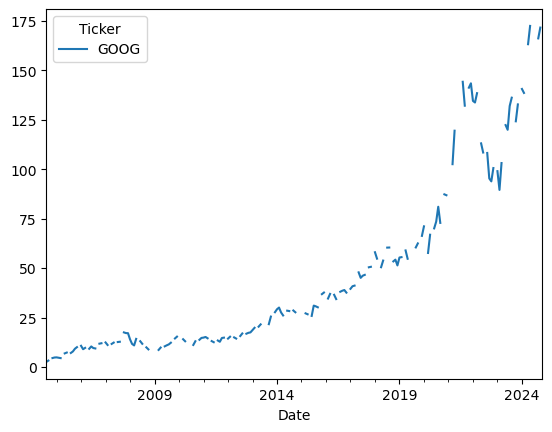

In [10]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('ME')
print(goog_downsampled)

goog_downsampled.plot()

In [12]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').median()
print(goog_upsampled)

Ticker                     GOOG
Date                           
2004-08-19 00:00:00    2.478782
2004-08-19 12:00:00         NaN
2004-08-20 00:00:00    2.675672
2004-08-20 12:00:00         NaN
2004-08-21 00:00:00         NaN
...                         ...
2024-12-28 00:00:00         NaN
2024-12-28 12:00:00         NaN
2024-12-29 00:00:00         NaN
2024-12-29 12:00:00         NaN
2024-12-30 00:00:00  191.807617

[14877 rows x 1 columns]


#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [15]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods=-900)
goog_shifted

Ticker,GOOG
Date,
2004-08-19,10.848932
2004-08-20,10.672052
2004-08-23,10.710343
2004-08-24,11.377593
2004-08-25,11.135990
...,...
2024-12-23,NaN
2024-12-24,NaN
2024-12-26,NaN


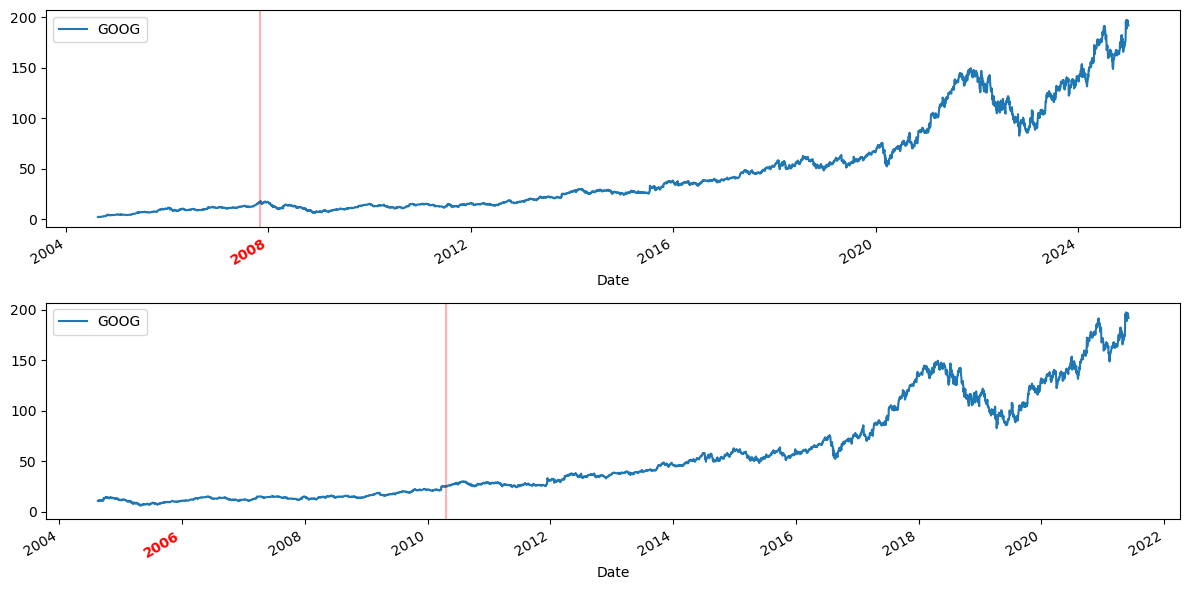

In [16]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [17]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods=1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted # [+] 주가 변화율 계산

Ticker,GOOG
Date,
2004-08-19,NaN
2004-08-20,0.079430
2004-08-23,0.010064
2004-08-24,-0.041408
2004-08-25,0.010775
...,...
2024-12-23,0.015703
2024-12-24,0.008062
2024-12-26,-0.002379


Ticker          GOOG
Date                
2004-08-19       NaN
2004-08-20  0.196889
2004-08-23  0.026927
2004-08-24 -0.111908
2004-08-25  0.027915
...              ...
2024-12-23  3.016129
2024-12-24  1.572754
2024-12-26 -0.467850
2024-12-27 -3.045990
2024-12-30 -1.343826

[5126 rows x 1 columns]


<Axes: xlabel='Date'>

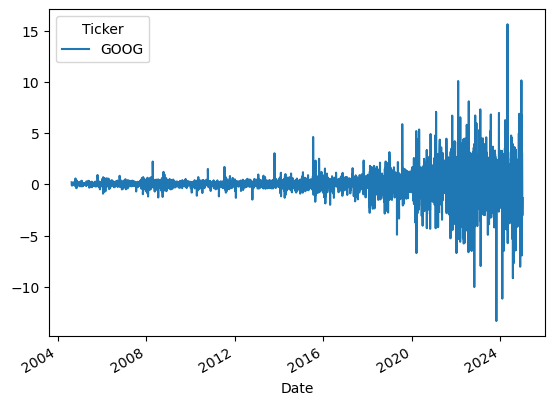

In [18]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog-goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

Rolling [window=365,center=False,axis=0,method=single]


<Axes: xlabel='Date'>

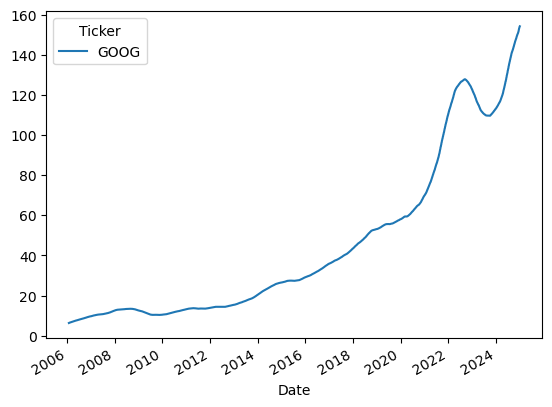

In [19]:
# [+] 365일 단위 윈도잉
goog_rolled = goog.rolling(365)
print(goog_rolled)

goog_rolled.mean().plot()

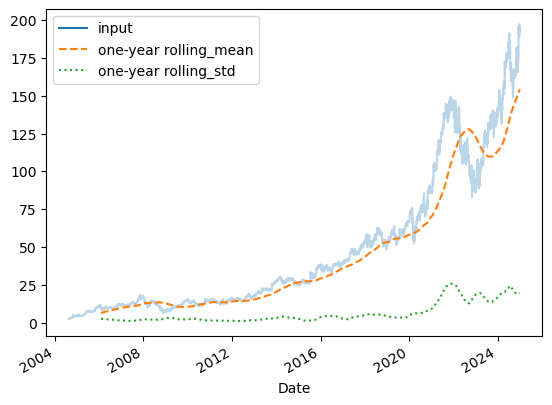

In [20]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)